In [98]:
import os
import bjontegaard as bd
import torch
import torch.utils.data
import numpy as np
import matplotlib.pyplot as plt
device = torch.device('cpu')
EXP_PATH = os.path.join('..', 'oslo_data', 'experiments')
CHP_PATH = os.path.join('..', 'oslo_data', 'checkpoints')
DATA_PATH = ...

In [99]:
# helper functions for RD curves and BD rate calculation
def get_bd_rates(anchor, rate_vals, spsnr_vals, wspsnr_vals):
    bd_rate_spsnr = bd.bd_rate(anchor['rate'], anchor['spsnr'], rate_vals, spsnr_vals, method='akima', require_matching_points=False)
    bd_rate_wspsnr = bd.bd_rate(anchor['rate'], anchor['wspsnr'], rate_vals, wspsnr_vals, method='akima', require_matching_points=False)
    return bd_rate_spsnr, bd_rate_wspsnr

def get_rd_points(exp_key:str, lambda_q_vals:list, exp_dir:str, lbd_chp=[], chp_result_dir:str='', summary_file:str='rate_spherical_psnrs_reconstruction.txt', th_rate:bool=False, rate_unit:str='KB', printvals:bool=False):
    spsnr_vals, wspsnr_vals, rate_vals = [], [], []
    for lbd, q in lambda_q_vals:
        cur_dir = exp_dir if lbd not in lbd_chp else chp_result_dir
        cur_key = exp_key if lbd not in lbd_chp else exp_key.split('_')[0]
        test_file = os.path.join(cur_dir, cur_key+f"_lambda_{lbd:.4f}_q_{q}", summary_file)
        try:
            with open(test_file) as f:
                avg_vals = f.readlines()[-1].split()
        except IndexError:
            print(f"File {test_file} is empty")
            continue
        spsnr_vals.append(float(avg_vals[3]))
        wspsnr_vals.append(float(avg_vals[4]))
        healpix_res = int(exp_key.split('_hr_')[1].split('_')[0]) if '_hr_' in exp_key else 10
        rate_factor = 8*1024 if rate_unit=='KB' else 12*4**healpix_res # KB or bpp
        rate_vals.append(float(avg_vals[-2 if th_rate else -1]) / rate_factor)
    if printvals:
        print(exp_key)
        print('S-PSNR:')
        [print(f"{r} {val}") for r, val in zip(rate_vals, spsnr_vals)];
        print('WS-PSNR:')
        [print(f"{r} {val}") for r, val in zip(rate_vals, wspsnr_vals)];
    return rate_vals, spsnr_vals, wspsnr_vals

def plot_rd_curve(axs, exp_key:str, lambda_q_vals:list, exp_dir:str, label=None, marker='o', markersize=3, linestyle='-', color=None, lbd_chp=[], chp_result_dir:str='', summary_file:str='rate_spherical_psnrs_reconstruction.txt', th_rate:bool=False, rate_unit:str='KB', anchor:dict={}, printvals:bool=False):
    rate_vals, spsnr_vals, wspsnr_vals = get_rd_points(exp_key, lambda_q_vals, exp_dir, lbd_chp, chp_result_dir, summary_file, th_rate, rate_unit, printvals)
    markeredgewidth = 1
    if len(rate_vals) == 1:
        linestyle = ''
        marker, markersize, markeredgewidth = '+', 20, 2.5
    label = exp_key if label is None else label
    label_spsnr, label_wspsnr = label, label
    if len(anchor)>1 and len(rate_vals)>1: # add BD rate
        bd_rate_spsnr, bd_rate_wspsnr = get_bd_rates(anchor, rate_vals, spsnr_vals, wspsnr_vals)
        label_spsnr += f" ({bd_rate_spsnr:.2f}%)"
        label_wspsnr += f" ({bd_rate_wspsnr:.2f}%)"
    if rate_vals: axs[0].plot(rate_vals, spsnr_vals, marker, linestyle=linestyle, label=label_spsnr, linewidth=1, markersize=markersize, markeredgewidth=markeredgewidth, color=color)
    if rate_vals: axs[1].plot(rate_vals, wspsnr_vals, marker, linestyle=linestyle, label=label_wspsnr, linewidth=1, markersize=markersize, markeredgewidth=markeredgewidth, color=color)

/home/wawerek/.conda/envs/oslo-gpu/lib/python3.8/site-packages/bjontegaard/bjontegaard_delta.py:54: UserWarning: Insufficient curve overlap: '9.01'. Minimum overlap: '75.00'. You can silence this warning by setting `min_overlap=0`
  warnings.warn(
/home/wawerek/.conda/envs/oslo-gpu/lib/python3.8/site-packages/bjontegaard/bjontegaard_delta.py:54: UserWarning: Insufficient curve overlap: '11.09'. Minimum overlap: '75.00'. You can silence this warning by setting `min_overlap=0`
  warnings.warn(


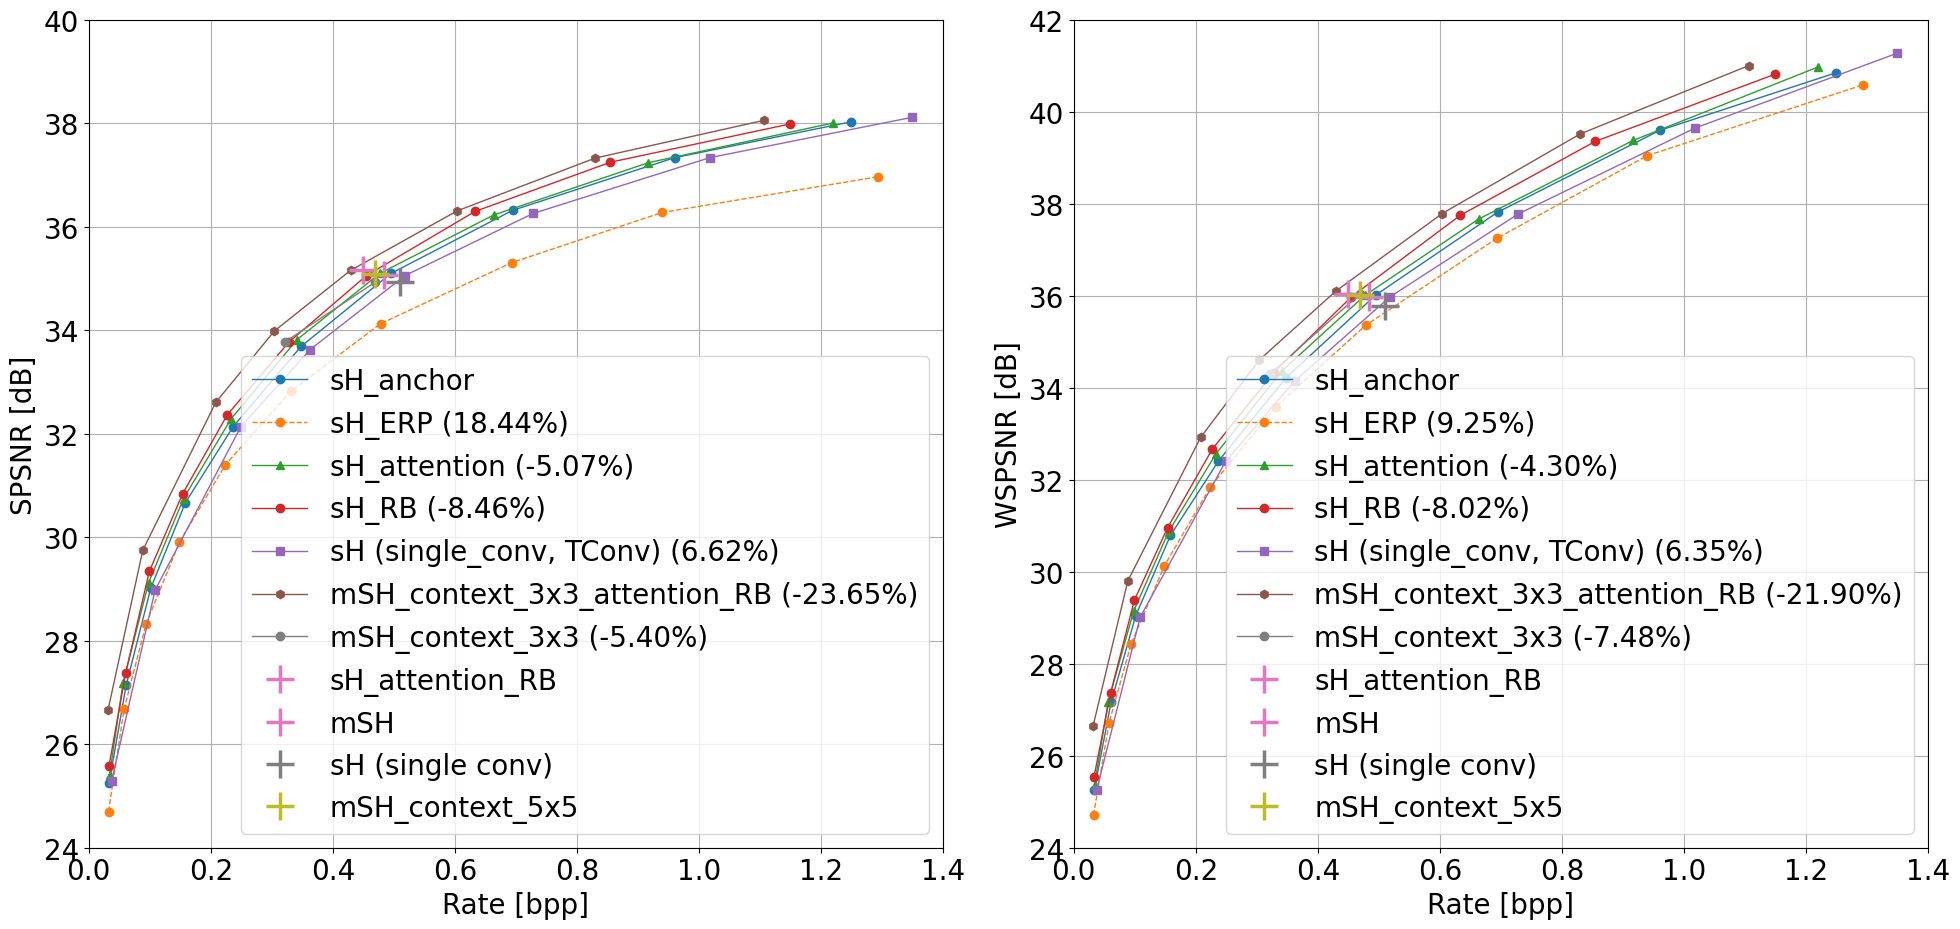

In [100]:
# plot RD curve hr 10
base_model = 'h' # 'f' or 'h'
title = ''#f"RD Curves {'Factorized Prior' if base_model=='f' else 'Hyperprior'}"
zoom = 0
print_vals = False
rate_unit = 'bpp'
linestyle, marker, markersize = '-', 'o', 6

plt.rcParams.update({'font.size': 20})
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
assert rate_unit in ['bpp', 'KB']
ch_results = os.path.join(CHP_PATH, 'checkpoint_results')
n_pix = 12*4**10

if base_model == 'f': # all results based on the Factorized Prior
    exp_key = 'factorizedPrior_rerun' # adapt
    lambda_q_vals = [ # adapt
        (0.0005,1),
        (0.0009,1), # gitlab
        (0.0018,1),
        (0.0035,2), # gitlab
        (0.0067,3),
        (0.0130,4), # gitlab
        (0.0250,5), # gitlab
        (0.0483,6), # gitlab
        (0.0932,7), # gitlab
        (0.1800,8), # gitlab
    ]
    lbd_chp = [x[0] for x in lambda_q_vals if x[0] not in [0.0005, 0.0018, 0.0067]]
    anchor_fP = dict(zip(('rate', 'spsnr', 'wspsnr'), get_rd_points(exp_key, lambda_q_vals, EXP_PATH, lbd_chp, ch_results, rate_unit=rate_unit)))
    plot_rd_curve(axs, exp_key, lambda_q_vals, EXP_PATH, label='fP_anchor', lbd_chp=lbd_chp, chp_result_dir=ch_results, printvals=print_vals, rate_unit=rate_unit, markersize=markersize)
    
    # ERP Training from paper
    rate_vals = [
        89.3442492675781,
        234.516705322266,
        557.610926513672,
        828.33169921875,
        1215.43615234375,
        1750.42578125,
        2417.47916625977,
    ]
    spsnr_vals = [
        26.27,
        29.18,
        32.09,
        33.5,
        34.81,
        35.92,
        36.79,
    ]
    wspsnr_vals = [
        26.29,
        29.31,
        32.57,
        34.34,
        36.29,
        38.22,
        40.07,
    ]
    if rate_unit == 'bpp':
        rate_vals = [r*8*1024/n_pix for r in rate_vals]
    bd_rate_spsnr, bd_rate_wspsnr = get_bd_rates(anchor_fP, rate_vals, spsnr_vals, wspsnr_vals)
    axs[0].plot(rate_vals, spsnr_vals, label=f'fP_Equirect ({bd_rate_spsnr:.2f}%)', linewidth=1, markersize=markersize, linestyle='--', marker=marker)
    axs[1].plot(rate_vals, wspsnr_vals, label=f'fP_Equirect ({bd_rate_wspsnr:.2f}%)', linewidth=1, markersize=markersize, linestyle='--', marker=marker)
    
    exp_key = 'factorizedPrior_attention'
    plot_rd_curve(axs, exp_key, lambda_q_vals, EXP_PATH, label='fP_attention', anchor=anchor_fP, printvals=print_vals, rate_unit=rate_unit, markersize=markersize)
    exp_key = 'factorizedPrior_RB'
    plot_rd_curve(axs, exp_key, lambda_q_vals, EXP_PATH, label='fP_RB', anchor=anchor_fP, printvals=print_vals, rate_unit=rate_unit, markersize=markersize)
    
    lambda_q_vals = [
        (0.0005,1),
        # (0.0009,1),
        (0.0018,1),
        # (0.0035,2),
        (0.0067,3),
        (0.0130,4),
        (0.0250,5),
        (0.0483,6),
        (0.0932,7),
        (0.1800,8),
    ]
    exp_key = 'factorizedPrior_single_conv_unpool_SDPAConvTranspose'
    plot_rd_curve(axs, exp_key, lambda_q_vals, EXP_PATH, th_rate=False, label='fP (single_conv, TConv)', anchor=anchor_fP, printvals=print_vals, rate_unit=rate_unit, markersize=markersize)
    
    lambda_q_vals = [(0.0250,5)]
    
    exp_key = 'factorizedPrior_single_conv'
    plot_rd_curve(axs, exp_key, lambda_q_vals, EXP_PATH, th_rate=False, label='fP (single conv)', rate_unit=rate_unit, markersize=markersize)
    exp_key = 'factorizedPrior_unpool_SDPAConvTranspose'
    plot_rd_curve(axs, exp_key, lambda_q_vals, EXP_PATH, th_rate=False, label='fP (TConv)', rate_unit=rate_unit, markersize=markersize)
    
    # exp_key = 'factorizedPrior_pretrained_conv2_diag_unpool_SDPAConvTranspose_val_start_1'
    # plot_rd_curve(axs, exp_key, lambda_q_vals, EXP_PATH, th_rate=False, label='fP_pretrained_double_conv (200 Epochs)', summary_file='rate_spherical_psnrs_reconstruction_200.txt', rate_unit=rate_unit, markersize=markersize)
    # exp_key = 'factorizedPrior_pretrained_conv2_diag_unpool_SDPAConvTranspose_val_start_1'
    # plot_rd_curve(axs, exp_key, lambda_q_vals, EXP_PATH, th_rate=False, label='fP_pretrained_double_conv (400 Epochs)', summary_file='rate_spherical_psnrs_reconstruction_400.txt', rate_unit=rate_unit, markersize=markersize)
    # exp_key = 'factorizedPrior_pretrained_conv2_diag_unpool_SDPAConvTranspose'
    # plot_rd_curve(axs, exp_key, lambda_q_vals, EXP_PATH, th_rate=False, label='fP_pretrained_double_conv (full training)', rate_unit=rate_unit, markersize=markersize)
    # exp_key = 'factorizedPrior_pretrained_single_conv_unpool_SDPAConvTranspose_val_start_1'
    # plot_rd_curve(axs, exp_key, lambda_q_vals, EXP_PATH, th_rate=False, label='fP_pretrained_single_conv (200 Epochs)', summary_file='rate_spherical_psnrs_reconstruction_200.txt', rate_unit=rate_unit, markersize=markersize)
    # exp_key = 'factorizedPrior_pretrained_single_conv_unpool_SDPAConvTranspose_val_start_1'
    # plot_rd_curve(axs, exp_key, lambda_q_vals, EXP_PATH, th_rate=False, label='fP_pretrained_single_conv (400 Epochs)', summary_file='rate_spherical_psnrs_reconstruction_400.txt', rate_unit=rate_unit, markersize=markersize)
    # exp_key = 'factorizedPrior_pretrained_single_conv_unpool_SDPAConvTranspose'
    # plot_rd_curve(axs, exp_key, lambda_q_vals, EXP_PATH, th_rate=False, label='fP_pretrained_single_conv (full training)', rate_unit=rate_unit, markersize=markersize)
        
    r_lim = [700, 1000] if zoom else [0, 2500]
    spsnr_lim = [33, 36] if zoom else [24, 40]
    wspsnr_lim = [33.5, 36.5] if zoom else [24, 42]

if base_model == 'h': # all results based on the Hyperprior
    exp_key = 'scaleHyperprior_rerun'
    lambda_q_vals = [
        (0.0005,1), # only gitlab
        (0.0009,1), # only gitlab
        (0.0018,1),
        (0.0035,2),
        (0.0067,3),
        (0.0130,4),
        (0.0250,5),
        (0.0483,6),
        (0.0932,7),
        (0.1800,8),
    ]
    lbd_chp = [0.0005, 0.0009]
    anchor_sH = dict(zip(('rate', 'spsnr', 'wspsnr'), get_rd_points(exp_key, lambda_q_vals, EXP_PATH, lbd_chp, ch_results, rate_unit=rate_unit)))
    plot_rd_curve(axs, exp_key, lambda_q_vals, EXP_PATH, label='sH_anchor', lbd_chp=lbd_chp, chp_result_dir=ch_results, printvals=print_vals, rate_unit=rate_unit, markersize=markersize)
    # ERP Training from paper
    rate_vals = [
        49.7451977539062,
        88.9248852539063,
        144.388436279297,
        228.041002197266,
        343.580277099609,
        508.268247070312,
        734.825557861328,
        1064.84652099609,
        1443.90678588867,
        1986.89565795898,
    ]
    spsnr_vals = [
        24.7,
        26.68,
        28.33,
        29.9,
        31.4,
        32.82,
        34.13,
        35.31,
        36.28,
        36.97,
    ]
    wspsnr_vals = [
        24.71,
        26.72,
        28.43,
        30.13,
        31.84,
        33.59,
        35.36,
        37.25,
        39.05,
        40.59,
    ]
    if rate_unit == 'bpp':
        rate_vals = [r*8*1024/n_pix for r in rate_vals]
    bd_rate_spsnr, bd_rate_wspsnr = get_bd_rates(anchor_sH, rate_vals, spsnr_vals, wspsnr_vals)
    axs[0].plot(rate_vals, spsnr_vals, label=f'sH_ERP ({bd_rate_spsnr:.2f}%)', marker=marker, linestyle='--', linewidth=1, markersize=markersize)
    axs[1].plot(rate_vals, wspsnr_vals, label=f'sH_ERP ({bd_rate_wspsnr:.2f}%)', marker=marker, linestyle='--', linewidth=1, markersize=markersize)
    
    exp_key = 'scaleHyperprior_attention'
    plot_rd_curve(axs, exp_key, lambda_q_vals, EXP_PATH, label='sH_attention', marker='^', anchor=anchor_sH, printvals=print_vals, rate_unit=rate_unit, markersize=markersize)
    exp_key = 'scaleHyperprior_RB'
    plot_rd_curve(axs, exp_key, lambda_q_vals, EXP_PATH, label='sH_RB', anchor=anchor_sH, printvals=print_vals, rate_unit=rate_unit, markersize=markersize)
    lambda_q_vals = [
        (0.0005,1),
        (0.0018,1),
        (0.0067,3),
        (0.0130,4),
        (0.0250,5),
        (0.0483,6),
        (0.0932,7),
        (0.1800,8),
    ]
    exp_key = 'scaleHyperprior_single_conv_unpool_SDPAConvTranspose'
    plot_rd_curve(axs, exp_key, lambda_q_vals, EXP_PATH, th_rate=False, label='sH (single_conv, TConv)', marker='s', linestyle=linestyle, anchor=anchor_sH, printvals=print_vals, rate_unit=rate_unit, markersize=markersize)

    exp_key = 'meanScaleHyperprior_cm_ar_arhops_1_attention_RB'
    plot_rd_curve(axs, exp_key, lambda_q_vals, EXP_PATH, th_rate=False, label='mSH_context_3x3_attention_RB', marker='h', anchor=anchor_sH, printvals=print_vals, rate_unit=rate_unit, markersize=markersize)
    
    lambda_q_vals = [
        (0.0130,4),
        (0.0250,5),
    ]
    exp_key = 'meanScaleHyperprior_cm_ar_arhops_1'
    plot_rd_curve(axs, exp_key, lambda_q_vals, EXP_PATH, th_rate=False, label='mSH_context_3x3', anchor=anchor_sH, rate_unit=rate_unit, markersize=markersize, color='tab:gray')
    
    lambda_q_vals = [(0.0250,5)]
    exp_key = 'scaleHyperprior_attention_RB'
    plot_rd_curve(axs, exp_key, lambda_q_vals, EXP_PATH, label='sH_attention_RB', rate_unit=rate_unit, markersize=markersize)
    exp_key = 'meanScaleHyperprior'
    plot_rd_curve(axs, exp_key, lambda_q_vals, EXP_PATH, th_rate=False, label='mSH', summary_file='rate_spherical_psnrs_reconstruction.txt', rate_unit=rate_unit, markersize=markersize, color='tab:pink')
    
    exp_key = 'scaleHyperprior_single_conv'
    plot_rd_curve(axs, exp_key, lambda_q_vals, EXP_PATH, th_rate=False, label='sH (single conv)', rate_unit=rate_unit, markersize=markersize)
    
    exp_key = 'meanScaleHyperprior_cm_ar_arhops_2'
    plot_rd_curve(axs, exp_key, lambda_q_vals, EXP_PATH, th_rate=False, label='mSH_context_5x5', summary_file='rate_spherical_psnrs_reconstruction.txt', rate_unit=rate_unit, markersize=markersize, color='tab:olive')
    
    # exp_key = 'scaleHyperprior_pretrained_conv2_diag_unpool_SDPAConvTranspose_val_start_1'
    # plot_rd_curve(axs, exp_key, lambda_q_vals, EXP_PATH, th_rate=False, label='sH_pretrained_double_conv (200 Epochs)', summary_file='rate_spherical_psnrs_reconstruction_200.txt', rate_unit=rate_unit, markersize=markersize)
    # exp_key = 'scaleHyperprior_pretrained_conv2_diag_unpool_SDPAConvTranspose_val_start_1'
    # plot_rd_curve(axs, exp_key, lambda_q_vals, EXP_PATH, th_rate=False, label='sH_pretrained_double_conv (400 Epochs)', summary_file='rate_spherical_psnrs_reconstruction_400.txt', rate_unit=rate_unit, markersize=markersize)
    # exp_key = 'scaleHyperprior_pretrained_single_conv_unpool_SDPAConvTranspose_val_start_1'
    # plot_rd_curve(axs, exp_key, lambda_q_vals, EXP_PATH, th_rate=False, label='sH_pretrained (single_conv, 200 Epochs)', marker='o', linestyle='', summary_file='rate_spherical_psnrs_reconstruction_200.txt', rate_unit=rate_unit, markersize=markersize)
    # exp_key = 'scaleHyperprior_pretrained_single_conv_unpool_SDPAConvTranspose_val_start_1'
    # plot_rd_curve(axs, exp_key, lambda_q_vals, EXP_PATH, th_rate=False, label='sH_pretrained (single_conv, 400 Epochs)', marker='o', linestyle='', summary_file='rate_spherical_psnrs_reconstruction_400.txt', rate_unit=rate_unit, markersize=markersize)
    # exp_key = 'scaleHyperprior_pretrained_single_conv_unpool_SDPAConvTranspose'
    # plot_rd_curve(axs, exp_key, lambda_q_vals, EXP_PATH, th_rate=False, label='sH_pretrained (single_conv, full training)', marker='o', linestyle='', rate_unit=rate_unit, markersize=markersize)
    
    r_lim = [600, 900] if zoom else [0, 2500]
    spsnr_lim = [33, 35.5] if zoom else [24, 40]
    wspsnr_lim = [33.5, 36.5] if zoom else [24, 42]

if rate_unit == 'bpp':
    r_lim = [r*8*1024/n_pix for r in r_lim] if zoom else [0,1.4]
axs[0].set_xlabel(f'Rate [{rate_unit}]')
axs[0].set_ylabel('SPSNR [dB]')
axs[0].set_xlim(r_lim)# paper: 0-2500, cropped: 600-900
axs[0].set_ylim(spsnr_lim)# paper: 24-38, cropped: 34-36
axs[0].legend(loc='lower right')
axs[0].grid()
axs[1].set_xlabel(f'Rate [{rate_unit}]')
axs[1].set_ylabel('WSPSNR [dB]')
axs[1].set_xlim(r_lim)# paper: 0-2500, cropped: 600-900
axs[1].set_ylim(wspsnr_lim)# paper: 24-40, cropped: 35-37
axs[1].legend(loc='lower right')
axs[1].grid()
fig.suptitle(title)
fig.tight_layout()
plt.show()

scaleHyperprior_rerun_loss_0959: 1.1489
scaleHyperprior_rerun_loss_val_0159: 0.9146
scaleHyperprior_pretrained_conv2_diag_unpool_SDPAConvTranspose_val_start_1_loss_0280: 1.2345
scaleHyperprior_pretrained_conv2_diag_unpool_SDPAConvTranspose_val_start_1_loss_val_0280: 1.0280


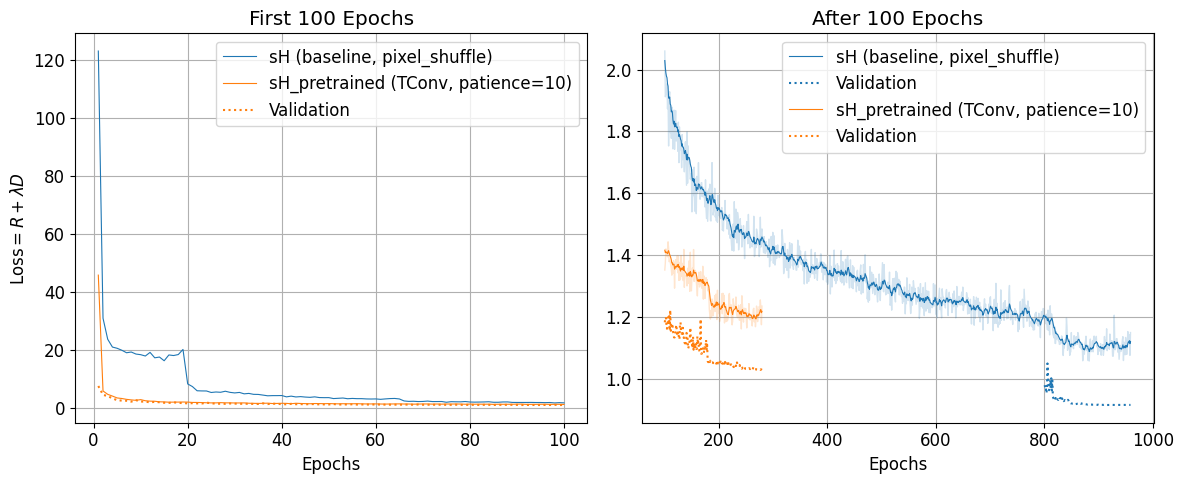

In [103]:
plt.rcParams.update({'font.size': 12})
value = 'loss' # one of [loss, aux_loss, bpp, mse, psnr]
lbd, q = 0.0250, 5
val_linestyle = ':'
colors = None
# predefined comparisons (can be adapted analogously):
comp_str = 'sH_pretrained_conv2'
if comp_str =='sH_pretrained_conv2':
    experiments = [
        'scaleHyperprior_rerun',
        'scaleHyperprior_pretrained_conv2_diag_unpool_SDPAConvTranspose_val_start_1',
    ]
    exp_labels = [
        'sH (baseline, pixel_shuffle)',
        'sH_pretrained (TConv, patience=10)',
    ]
    checkpoints = [
    'best_loss',
    'best_loss',
]
elif comp_str == 'sH_pretrained_single_conv':
    experiments = [
        'scaleHyperprior_single_conv_unpool_SDPAConvTranspose',
        'scaleHyperprior_pretrained_single_conv_unpool_SDPAConvTranspose',
        'scaleHyperprior_pretrained_single_conv_unpool_SDPAConvTranspose_val_start_1',
    ]
    exp_labels = [
        'sH_baseline (TConv)',
        'sH_pretrained (TConv, regular training)',
        'sH_pretrained (TConv, patience=10)',
    ]
    checkpoints = [
        'best_loss',
        'best_loss',
        'best_loss',
    ]
    colors = [
        'tab:blue',
        'tab:green',
        'tab:orange',
    ]

val_start = 1
first_epoch, max_epoch = 1, 1000
legend = []
ep_threshold = 100
split_plot = first_epoch < ep_threshold and max_epoch > ep_threshold
if split_plot:
    plt.subplots(1, 2, figsize=(12, 5))
else:
    plt.figure(figsize=(10, 5))
    
def ema(x, decay=0.999):
    'exponential moving average'
    x = np.array(x)
    s = np.zeros(x.shape)
    s[0] = x[0]
    for t in range(1, x.shape[0]):
        s[t] = decay * x[t] + (1-decay) * s[t-1]
    return s
inputs = [experiments, exp_labels, checkpoints]
if colors: inputs.append(colors)
for input in zip(*inputs):
    if colors:
        exp, label, chp, color = input
    else:
        exp, label, chp = input
        color = next(plt.gca()._get_lines.prop_cycler)['color']
    legend += [label]
    checkpoint = torch.load(os.path.join(EXP_PATH, exp+f'_lambda_{lbd:.4f}_q_{q}', f"{'checkpoint_' if chp!='final' else ''}{chp}.pth.tar"), map_location='cpu')
    last_epoch = checkpoint['epoch'] + 1
    y = [epoch_dict[value if value!='psnr' else 'mse'] for epoch_dict in checkpoint['list_mean_losses'][:min(max_epoch, last_epoch)]]
    if value=='psnr':
        y = [20*np.log10(256/np.sqrt(loss)) for loss in y]
    print(f'{exp}_loss_{len(y):04d}: {y[-1]:.4f}')
    x = np.arange(1, min(max_epoch, last_epoch)+1)
    y_ema = ema(y, decay=0.2)
    if split_plot:
        if last_epoch > ep_threshold:
            plt.subplot(121)
            plt.plot(x[first_epoch-1:ep_threshold], y[first_epoch-1:ep_threshold], linewidth=.8, color=color, label=legend[-1])
            plt.subplot(122)
            plt.plot(x[ep_threshold:], y_ema[ep_threshold:], linewidth=.8, color=color, alpha=1, label=legend[-1])
            plt.plot(x[ep_threshold:], y[ep_threshold:], linewidth=1, color=color, alpha=0.2)
        else:
            plt.subplot(121)
            plt.plot(x[first_epoch-1:], y[first_epoch-1:], linewidth=1, color=color, label=legend[-1])
    else:
        plt.plot(x[first_epoch-1:], y[first_epoch-1:], linewidth=1, color=color)
    if 'list_mean_losses_validation' in checkpoint.keys():
        start_idx_val = max(first_epoch, val_start)-1
        y_val = [epoch_dict[value if value!='psnr' else 'mse'] for epoch_dict in checkpoint['list_mean_losses_validation'][start_idx_val:min(max_epoch, last_epoch)] if epoch_dict is not None]
        if not y_val: continue
        legend.append("Validation")
        if value=='psnr':
            y_val = [20*np.log10(256/np.sqrt(loss)) for loss in y_val]
        print(f'{exp}_loss_val_{len(y_val):04d}: {y_val[-1]:.4f}')
        x_val = x[-len(y_val):]
        if split_plot:
            if last_epoch > ep_threshold:
                if x_val[0] <= ep_threshold:
                    plt.subplot(121)
                    x_val1 = x[x_val[0]-1:ep_threshold]
                    plt.plot(x_val1, y_val[:len(x_val1)], linewidth=1.5, color=color, linestyle=val_linestyle, label=legend[-1])
                    y_val = y_val[len(x_val1):]
                plt.subplot(122)
                plt.plot(x[-len(y_val):], y_val, linewidth=1.5, color=color, linestyle=val_linestyle, label=legend[-1])
            else:
                x_val1 = x[x_val[0]-1:]
                plt.subplot(121)
                plt.plot(x_val1, y_val[:len(x_val1)], linewidth=1.5, color=color, linestyle=val_linestyle, label=legend[-1])
        else:
            plt.plot(x_val, y_val, linewidth=1.5, color=color, linestyle=val_linestyle)

y_label = value.capitalize()
if value=='loss': y_label += "$ = R + \\lambda D$"
if split_plot:
    plt.subplot(121)
    plt.legend()
    plt.grid()
    plt.xlabel('Epochs')
    plt.ylabel(y_label)
    plt.title(f"First {ep_threshold} Epochs")
    plt.subplot(122)
    plt.legend()
    plt.grid()
    plt.xlabel('Epochs')
    plt.title(f"After {ep_threshold} Epochs")
else:
    plt.legend(legend)
    plt.grid()
    plt.xlabel('Epochs')
    plt.ylabel(y_label)
    plt.title(f"First {max_epoch} Epochs")
plt.tight_layout()
plt.show()

******************** Weights ********************
OSLO vs. CompressAI
g_a.0.list_conv.0.weight: (9, 3, 128)
mean_abs:  0.02646 vs.  0.09301
std_abs :  0.01644 vs.  0.07228
max_abs :  0.08538 vs.  0.42996
min_abs :  0.00003 vs.  0.00003
g_a.0.list_conv.1.weight: (9, 128, 128)
mean_abs:  0.01780 vs.  0.00016
std_abs :  0.01746 vs.  0.00238
max_abs :  0.24738 vs.  0.10120
min_abs :  0.00000 vs.  0.00000
g_a.1.list_conv.0.weight: (9, 128, 128)
mean_abs:  0.02203 vs.  0.08863
std_abs :  0.02288 vs.  0.08625
max_abs :  0.30311 vs.  1.18660
min_abs :  0.00000 vs.  0.00000
g_a.1.list_conv.1.weight: (9, 128, 128)
mean_abs:  0.02304 vs.  0.00002
std_abs :  0.02488 vs.  0.00037
max_abs :  0.29772 vs.  0.01706
min_abs :  0.00000 vs.  0.00000
g_a.2.list_conv.0.weight: (9, 128, 128)
mean_abs:  0.01824 vs.  0.09112
std_abs :  0.01797 vs.  0.10101
max_abs :  0.20011 vs.  2.16374
min_abs :  0.00000 vs.  0.00000
g_a.2.list_conv.1.weight: (9, 128, 128)
mean_abs:  0.01661 vs.  0.00002
std_abs :  0.01677 v

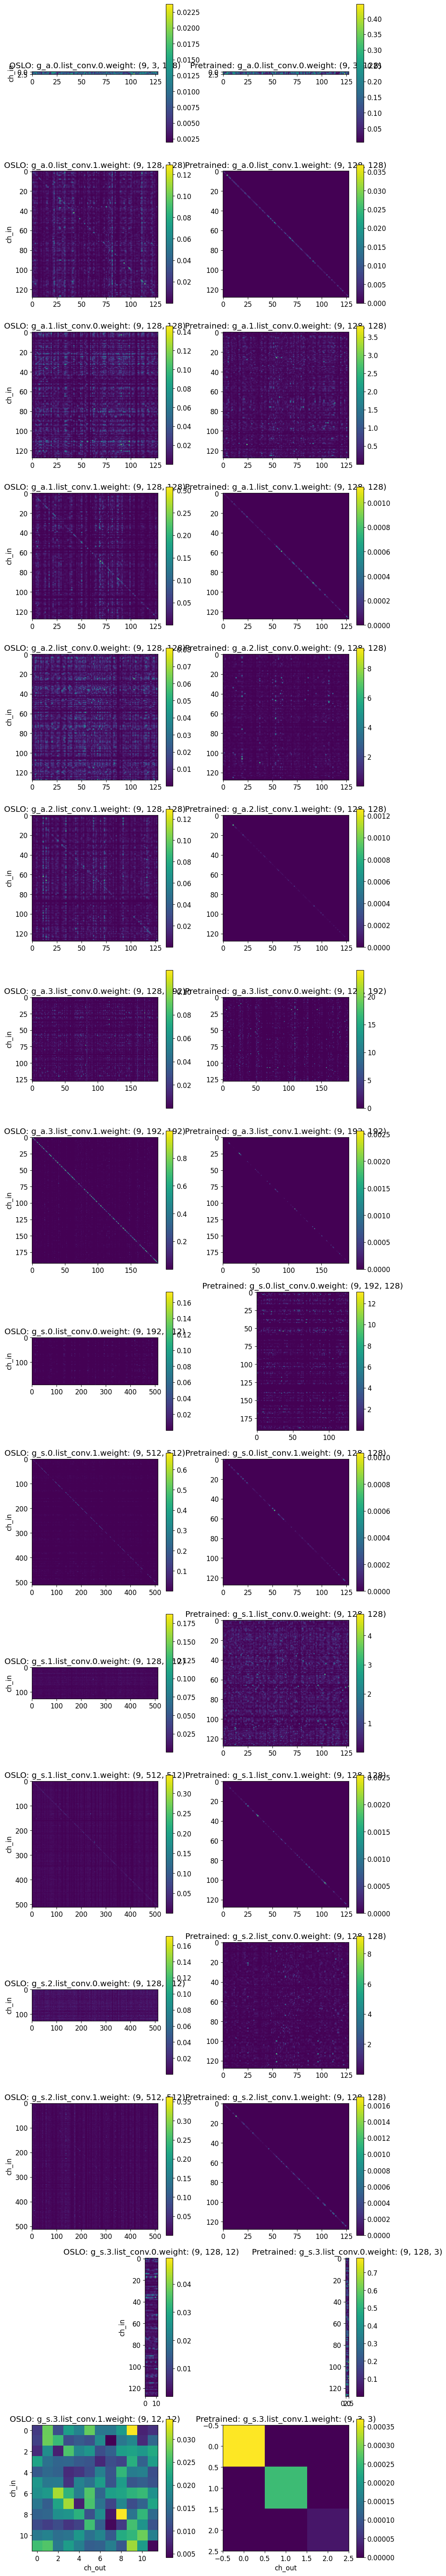

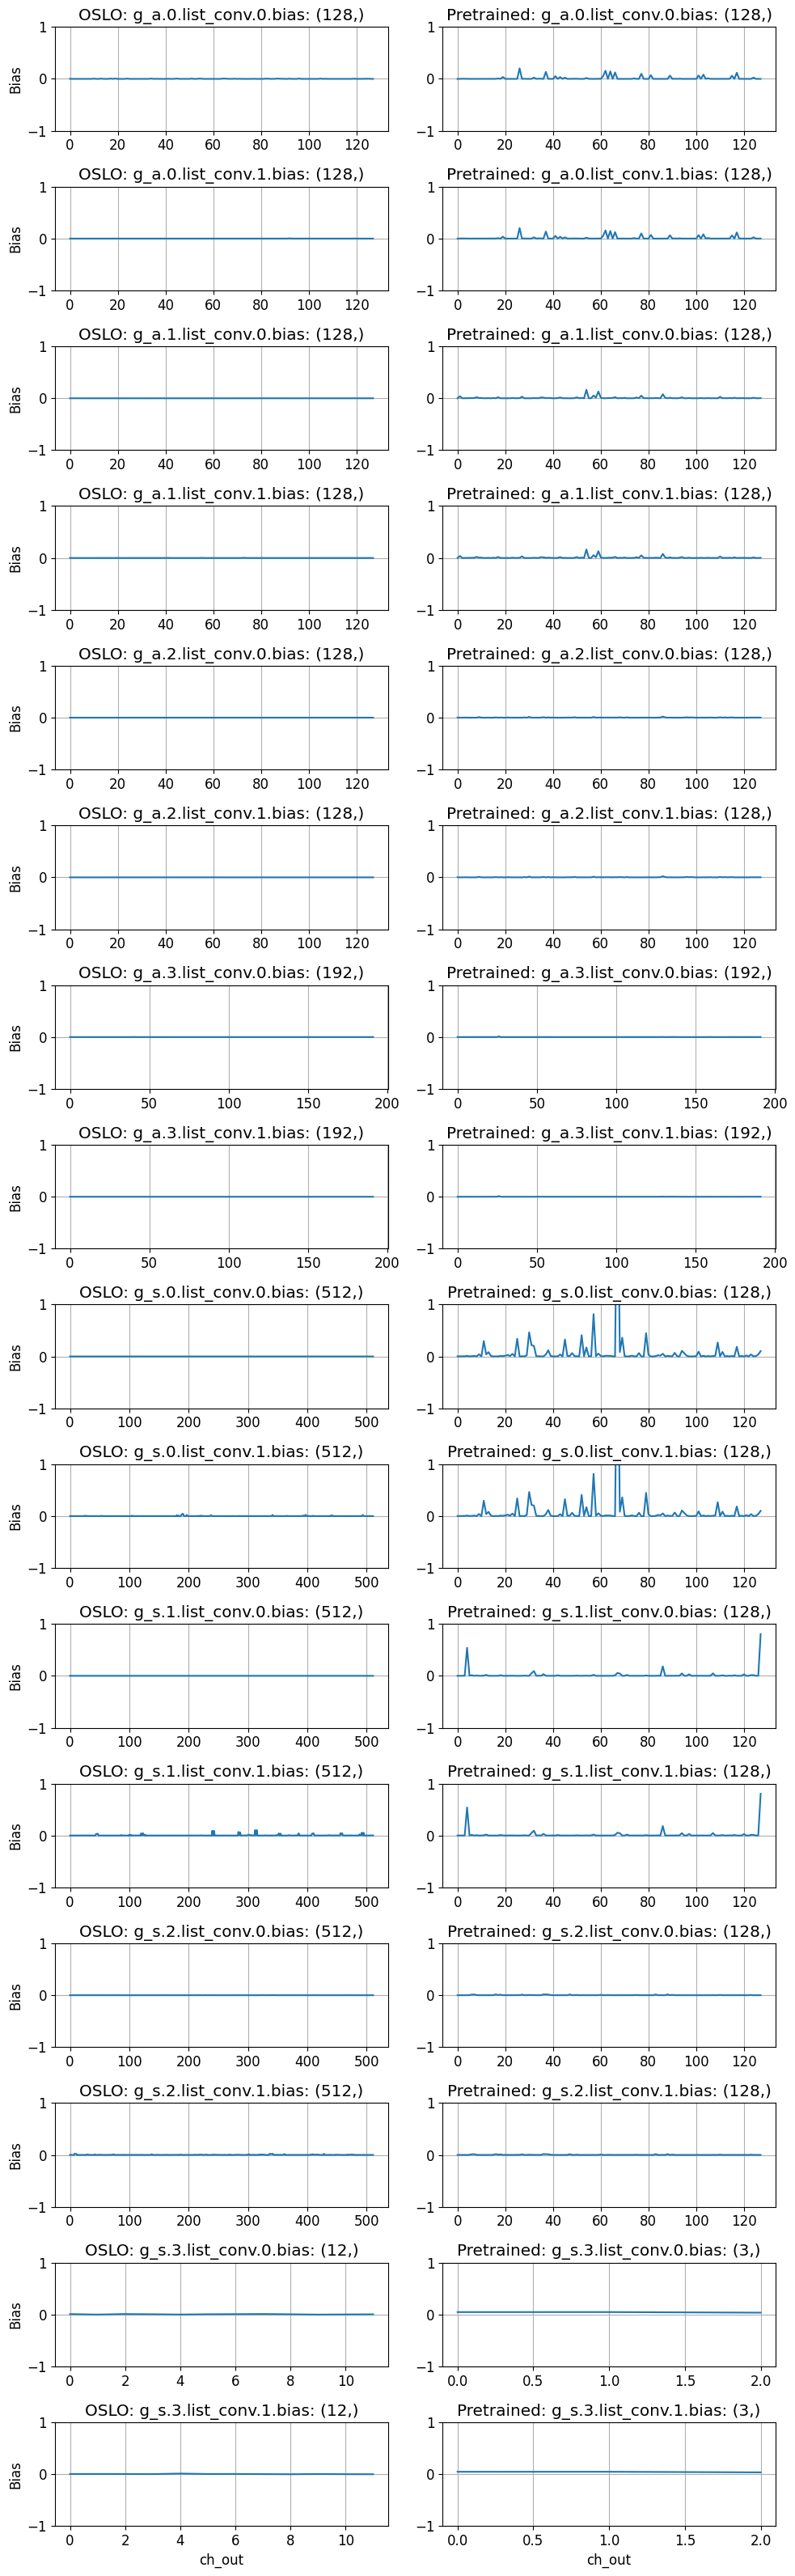

In [104]:
# show weight distribution
import os, torch
from utils import weight_transfer as wt_utils
import numpy as np
import matplotlib.pyplot as plt
EXP_PATH = os.path.join('..', 'oslo_data', 'experiments')
CHP_PATH = os.path.join('..', 'oslo_data', 'checkpoints')
PLOTS = True
print_stat_vals = True

def print_stats(key:str, model_sph, model_pre):
    print(f"{key}: {tuple(model_sph[key].shape)}")
    print(f"{'mean_abs':<8}: {model_sph[key].abs().mean():=8.5f} vs. {model_pre[key].abs().mean():=8.5f}")
    print(f"{'std_abs':<8}: {model_sph[key].abs().std():=8.5f} vs. {model_pre[key].abs().std():=8.5f}")
    print(f"{'max_abs':<8}: {model_sph[key].abs().max():=8.5f} vs. {model_pre[key].abs().max():=8.5f}")
    print(f"{'min_abs':<8}: {model_sph[key].abs().min():=8.5f} vs. {model_pre[key].abs().min():=8.5f}")
    
fps = [
    os.path.join(EXP_PATH, 'factorizedPrior_rerun_lambda_0.0250_q_5', 'checkpoint_best_loss.pth.tar'),
    os.path.join(CHP_PATH, 'pretrained', 'factorizedPrior_pretrained_lambda_0.0250_q_5.pth.tar'),
]
model_sph = torch.load(fps[0], map_location='cpu')['net_state_dict']
model_pre = wt_utils.transform_state_dict(torch.load(fps[1], map_location='cpu'), single_conv=False)
weight_keys = [key for key in model_sph.keys() if '.weight' in key]
bias_keys = [key for key in model_sph.keys() if '.bias' in key]
print("*"*20, "Weights", "*"*20)
print('OSLO vs. CompressAI')
plt.subplots(len(weight_keys), 2, figsize=(10, 4*len(weight_keys)))
for i, key in enumerate(weight_keys):
    if print_stat_vals: print_stats(key, model_sph, model_pre)
    if PLOTS:
        means_sph = model_sph[key].pow(2).sum((0))
        means_pre = model_pre[key].pow(2).sum((0))
        plt.subplot(len(weight_keys), 2, i*2+1)
        plt.imshow(means_sph.cpu().numpy())
        plt.colorbar()
        plt.title(f"OSLO: {key}: {tuple(model_sph[key].shape)}")
        if i == len(weight_keys)-1:
            plt.xlabel('ch_out')
        plt.ylabel('ch_in')
        plt.tight_layout()
        plt.subplot(len(weight_keys), 2, (i+1)*2)
        plt.imshow(means_pre.cpu().numpy())
        plt.colorbar()
        plt.title(f"Pretrained: {key}: {tuple(model_pre[key].shape)}")
        if i == len(weight_keys)-1:
            plt.xlabel('ch_out')
        plt.tight_layout()
        
print("*"*20, "Bias", "*"*20)
print('OSLO vs. CompressAI')
plt.subplots(len(bias_keys), 2, figsize=(10, 2*len(bias_keys)))
for i, key in enumerate(bias_keys):
    if print_stat_vals: print_stats(key, model_sph, model_pre)
    if PLOTS:
        bias_sph = model_sph[key].pow(2)
        bias_pre = model_pre[key].pow(2)
        plt.subplot(len(bias_keys), 2, i*2+1)
        plt.plot(np.arange(len(bias_sph)), bias_sph.cpu().numpy())
        plt.title(f"OSLO: {key}: {tuple(model_sph[key].shape)}")
        if i == len(bias_keys)-1:
            plt.xlabel('ch_out')
        plt.ylabel('Bias')
        plt.ylim([-1, 1])
        plt.grid()
        plt.subplot(len(bias_keys), 2, (i+1)*2)
        plt.plot(np.arange(len(bias_pre)), bias_pre.cpu().numpy())
        plt.title(f"Pretrained: {key}: {tuple(model_pre[key].shape)}")
        if i == len(bias_keys)-1:
            plt.xlabel('ch_out')
        plt.ylim([-1, 1])
        plt.grid()
        plt.tight_layout()
plt.show()

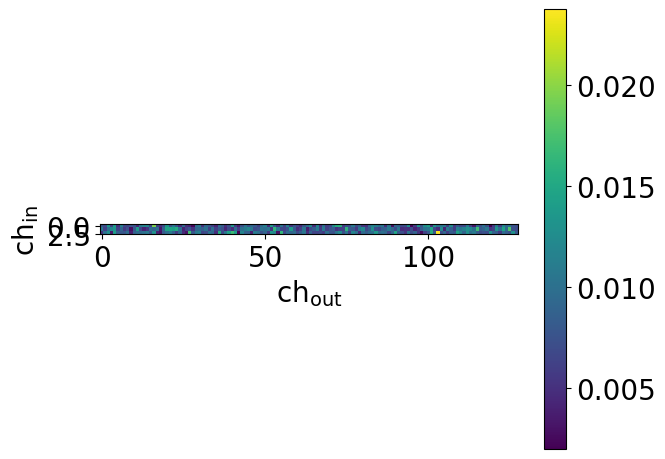

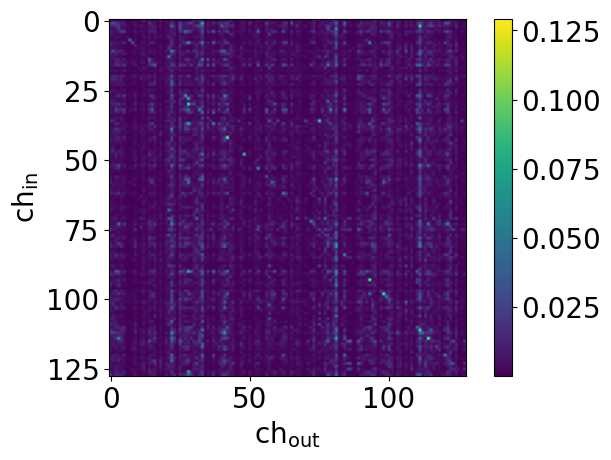

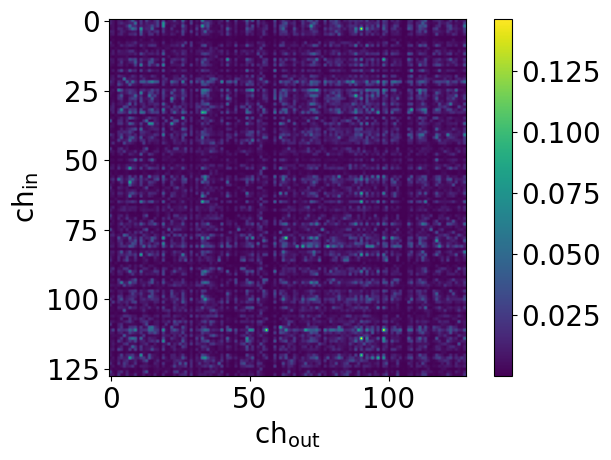

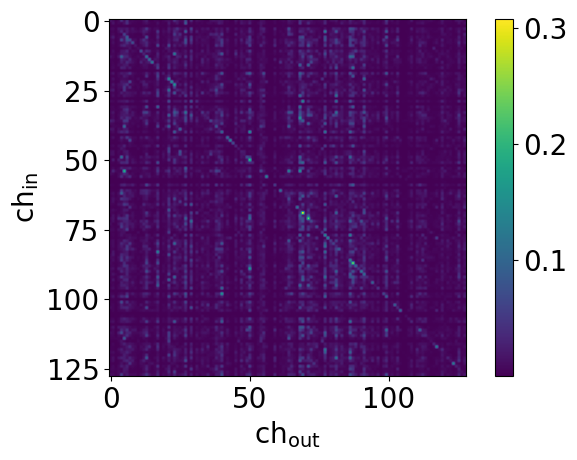

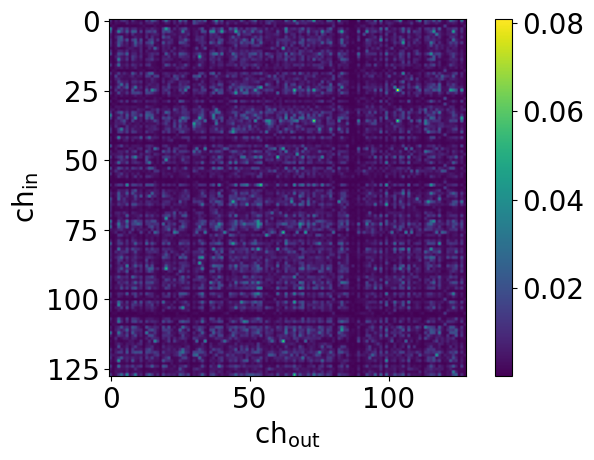

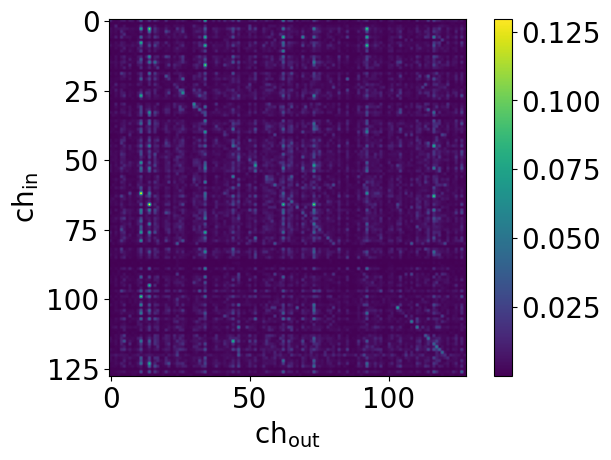

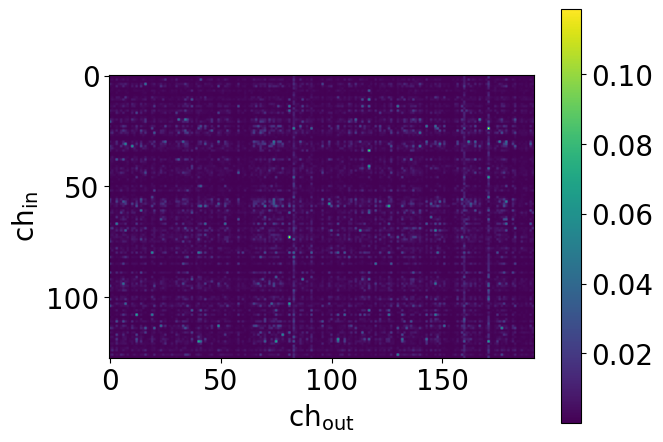

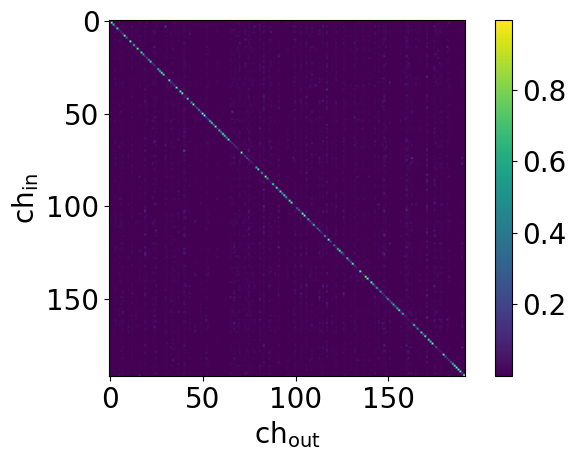

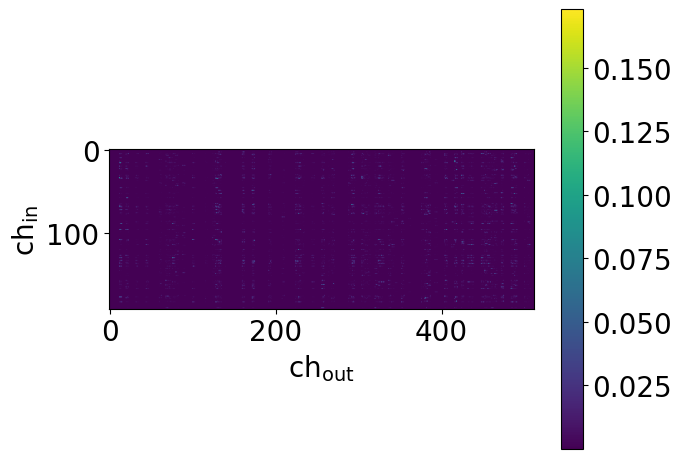

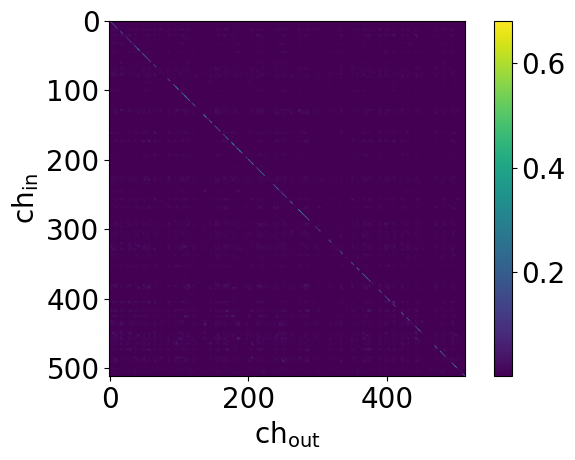

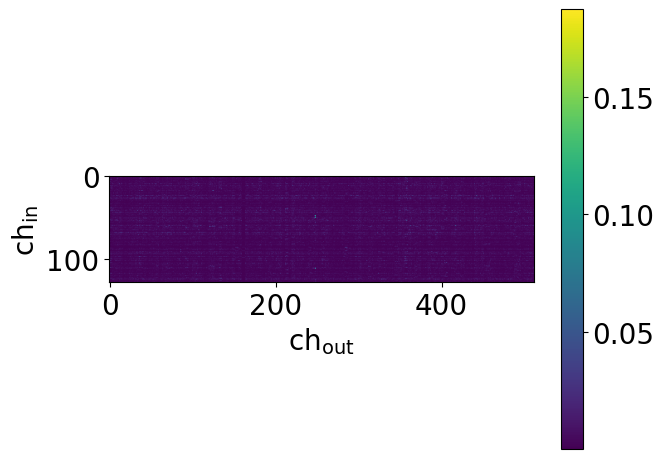

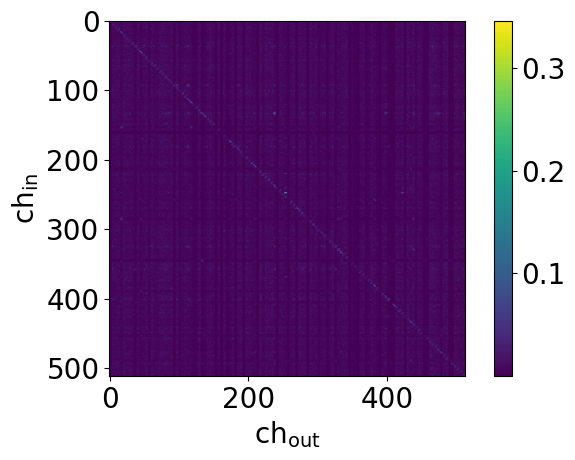

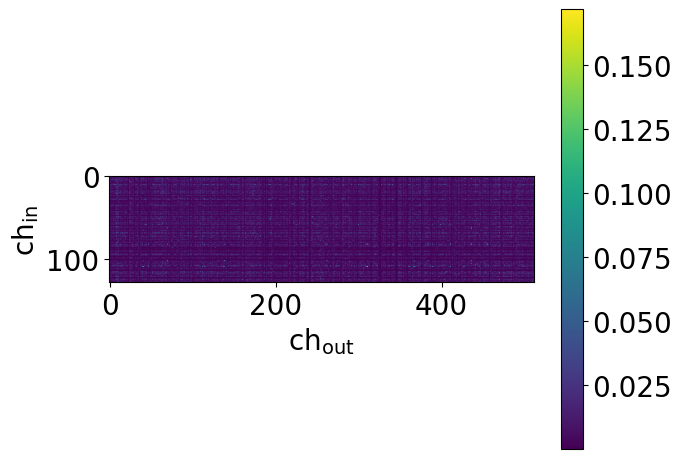

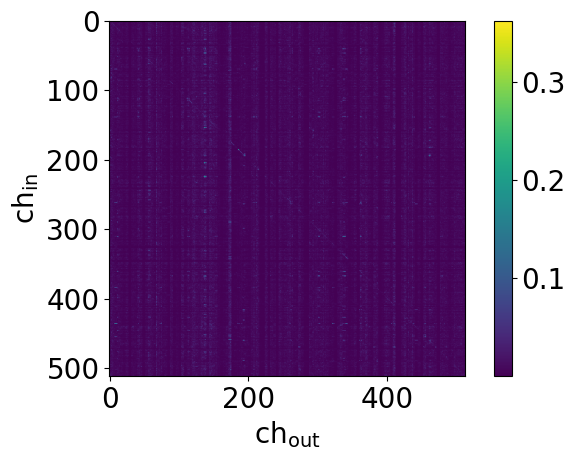

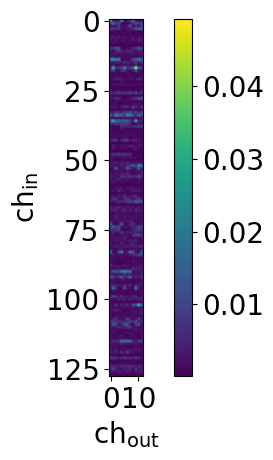

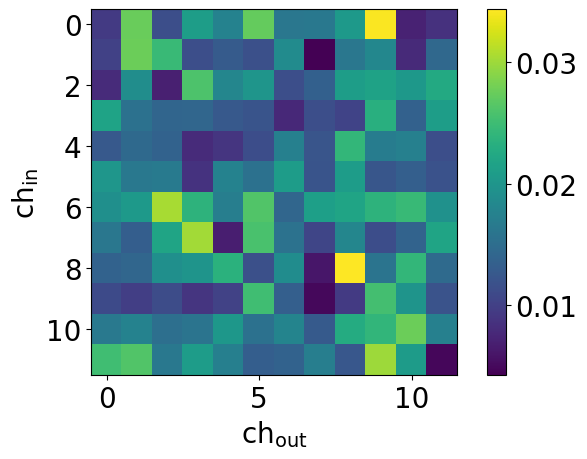

In [84]:
# save weight distribution
import os, torch
from utils import weight_transfer as wt_utils
import numpy as np
import matplotlib.pyplot as plt
EXP_PATH = os.path.join('..', 'oslo_data', 'experiments')
CHP_PATH = os.path.join('..', 'oslo_data', 'checkpoints')
    
fps = [
    os.path.join(EXP_PATH, 'factorizedPrior_rerun_lambda_0.0250_q_5', 'checkpoint_best_loss.pth.tar'),
    os.path.join(CHP_PATH, 'pretrained', 'factorizedPrior_pretrained_lambda_0.0250_q_5.pth.tar'),
]
model_sph = torch.load(fps[0], map_location='cpu')['net_state_dict']
weight_keys = [key for key in model_sph.keys() if '.weight' in key]
for i, key in enumerate(weight_keys):
    means_sph = model_sph[key].pow(2).sum((0))
    plt.figure(figsize=(7, 5))
    plt.imshow(means_sph.cpu().numpy())
    plt.colorbar()
    plt.xlabel('$\\mathrm{ch}_{\\mathrm{out}}$')
    plt.ylabel('$\\mathrm{ch}_{\\mathrm{in}}$')
    plt.tight_layout()

    # plt.savefig(os.path.join('..', 'sandbox_data', 'weight_vis', f'sH_weights_ch_{key}.png'))
    # plt.close()
        

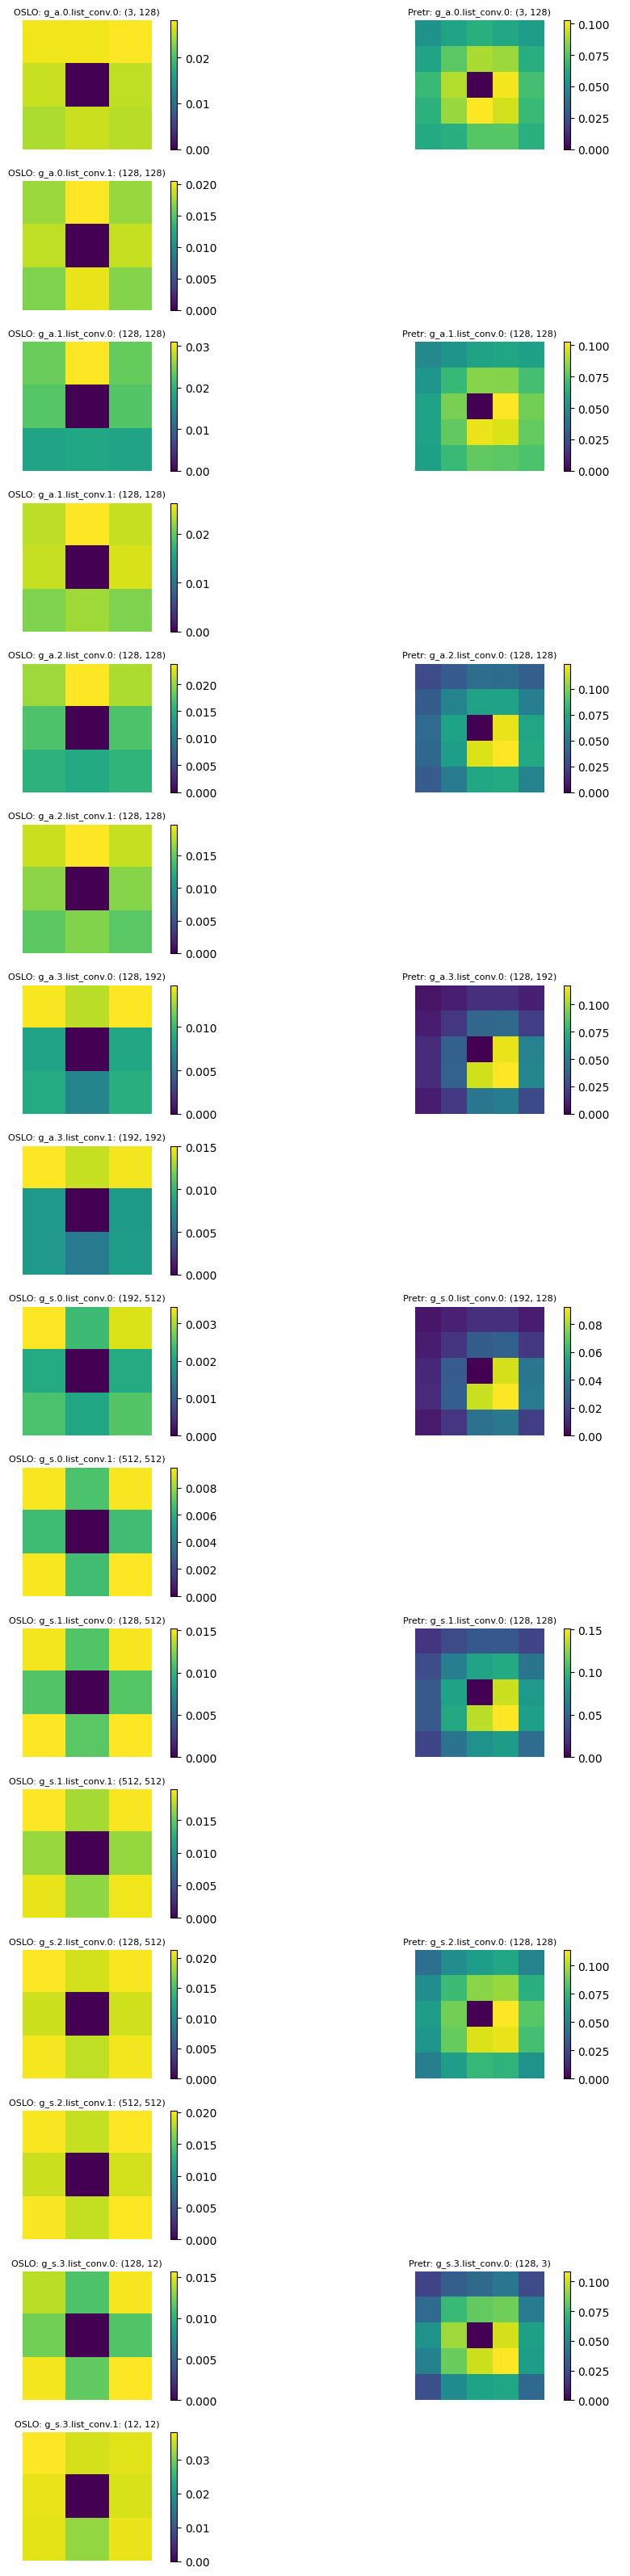

In [44]:
# show spatial weight distribution
import os, torch
from utils import weight_transfer as wt_utils
import numpy as np
import matplotlib.pyplot as plt
EXP_PATH = os.path.join('..', 'oslo_data', 'experiments')
CHP_PATH = os.path.join('..', 'oslo_data', 'checkpoints')
PLOTS = True
PRINT_STATS = False
SINGLE_CONV = True

def print_stats(key:str, model_sph, model_pre):
    print(f"{key}: {tuple(model_sph[key].shape)}")
    print(f"{'mean_abs':<8}: {model_sph[key].abs().mean():=8.5f} vs. {model_pre[key].abs().mean():=8.5f}")
    print(f"{'std_abs':<8}: {model_sph[key].abs().std():=8.5f} vs. {model_pre[key].abs().std():=8.5f}")
    print(f"{'max_abs':<8}: {model_sph[key].abs().max():=8.5f} vs. {model_pre[key].abs().max():=8.5f}")
    print(f"{'min_abs':<8}: {model_sph[key].abs().min():=8.5f} vs. {model_pre[key].abs().min():=8.5f}")
    
fps = [
    os.path.join(EXP_PATH, 'factorizedPrior_rerun_lambda_0.0250_q_5', 'checkpoint_best_loss.pth.tar'),
    os.path.join(CHP_PATH, 'pretrained', 'factorizedPrior_pretrained_lambda_0.0250_q_5.pth.tar'),
]
k = 5 if SINGLE_CONV else 3
hp2grid_sph = wt_utils.get_grid_order(1, include_center=True, start_sw=True)
hp2grid_pre = wt_utils.get_grid_order(k//2, include_center=True, start_sw=True)

model_sph = torch.load(fps[0], map_location='cpu')['net_state_dict']
model_pre = wt_utils.transform_state_dict(torch.load(fps[1], map_location='cpu'), SINGLE_CONV)
weight_keys = [key for key in model_sph.keys() if '.weight' in key][:]
if PRINT_STATS: print("*"*20, "Weights", "*"*20)
if PRINT_STATS: print('OSLO vs. CompressAI')
fig, _ = plt.subplots(len(weight_keys), 2, figsize=(10, 2*len(weight_keys)))
# plt.suptitle('Spatial Weight Distribution (abs mean, OSLO vs. Pretrained, North @ top center)')
for i, key in enumerate(weight_keys):
    if PRINT_STATS: print_stats(key, model_sph, model_pre)
    if PLOTS:
        ch_sph = model_sph[key].shape[1:]
        means_sph = model_sph[key][hp2grid_sph].view(3,3,*ch_sph).abs().mean((-2, -1))
        means_sph[1,1] = 0
        plt.subplot(len(weight_keys), 2, i*2+1)
        plt.imshow(means_sph.cpu().numpy())#, vmin=0, vmax=0.25)
        plt.axis('off')
        plt.colorbar()
        plt.title(f"OSLO: {key.replace('.weight', '')}: {tuple(model_sph[key].shape[1:])}", fontsize=8)
        plt.tight_layout()
        
        plt.subplot(len(weight_keys), 2, (i+1)*2)
        plt.axis('off')
        if not (SINGLE_CONV and 'conv.1' in key):
            ch_pre = model_pre[key].shape[1:]
            means_pre = model_pre[key][hp2grid_pre].view(k,k,*ch_pre).abs().mean((-2, -1))
            means_pre[k//2,k//2] = 0
        
            plt.imshow(means_pre.cpu().numpy())#, vmin=0, vmax=0.25)
            plt.colorbar()
            plt.title(f"Pretr: {key.replace('.weight', '')}: {tuple(model_pre[key].shape[1:])}", fontsize=8)
        plt.tight_layout()
        # print(key, 'plotted')
plt.show()